# ETF Data and Portfolio Setup

## tl;dr

- The Yahoo Finance CSV is read with its two-level `Price` / `Ticker` header and validated against four ETFs and five OHLCV fields.
- `2026-09-22` is identified as an invalid trailing market-data date because all four adjusted `Close` values are missing. It is removed only in memory; the raw CSV remains unchanged.
- Clean adjusted closes contain 2,191 observations from `2018-01-02` through `2026-09-21`. Simple daily returns contain 2,190 aligned observations from `2018-01-03` through `2026-09-21`, with no missing values.
- The fixed portfolio weights sum to 100%: SPY 40%, QQQ 25%, TLT 20%, and GLD 15%. The resulting portfolio return series has no missing values.
- This notebook prepares data only. It does **not** calculate VaR, Expected Shortfall, or backtests.

## Context & Methods

The source is `data/raw/etf_prices.csv`, downloaded with `auto_adjust=True`. Therefore the `Close` field used below is the adjusted close supplied by yfinance.

### Key Assumptions

- A date is invalid only when all four ETFs have missing `Close` prices. Volume is not used to establish price validity.
- Invalid dates must form a contiguous block at the end of the source data. Any internal all-missing date causes validation to fail.
- Prices are never filled, interpolated, or converted to zero.
- Simple returns are calculated as $P_t/P_{t-1}-1$ with `pct_change(fill_method=None)`.
- The portfolio is treated as a daily rebalanced constant-weight portfolio. Transaction costs, turnover, taxes, and implementation frictions are excluded.

## Data

### 1. Setup and Paths

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

project_root = Path.cwd().resolve()
if not (project_root / "data" / "raw" / "etf_prices.csv").exists():
    project_root = project_root.parent

RAW_DATA_PATH = project_root / "data" / "raw" / "etf_prices.csv"
ASSET_RETURNS_PATH = project_root / "data" / "processed" / "asset_returns.csv"
PORTFOLIO_RETURNS_PATH = project_root / "data" / "processed" / "portfolio_returns.csv"
NORMALIZED_FIGURE_PATH = project_root / "outputs" / "figures" / "normalized_prices.png"
CORRELATION_FIGURE_PATH = project_root / "outputs" / "figures" / "return_correlation_heatmap.png"

TICKERS = ["SPY", "QQQ", "TLT", "GLD"]
EXPECTED_FIELDS = ["Open", "High", "Low", "Close", "Volume"]
WEIGHTS = pd.Series(
    {"SPY": 0.40, "QQQ": 0.25, "TLT": 0.20, "GLD": 0.15},
    name="Weight",
    dtype="float64",
)

ASSET_STYLES = {
    "SPY": {"color": "#1F4E79", "linestyle": "-"},
    "QQQ": {"color": "#E07A5F", "linestyle": "--"},
    "TLT": {"color": "#6B8E23", "linestyle": "-."},
    "GLD": {"color": "#D4A72C", "linestyle": ":"},
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "legend.frameon": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

print(f"Project root: {project_root.relative_to(project_root)}")
print(f"Raw source:   {RAW_DATA_PATH.relative_to(project_root)}")

Project root: .
Raw source:   data/raw/etf_prices.csv


### 2. Read and Validate the Two-Level Header

In [2]:
raw_prices = pd.read_csv(
    RAW_DATA_PATH,
    header=[0, 1],
    index_col=0,
    parse_dates=True,
)
raw_prices.index.name = "Date"

expected_columns = {
    (field, ticker) for field in EXPECTED_FIELDS for ticker in TICKERS
}

assert not raw_prices.empty, "Raw price data is empty."
assert isinstance(raw_prices.columns, pd.MultiIndex), "Expected a MultiIndex header."
assert raw_prices.columns.nlevels == 2, "Expected exactly two column levels."
assert list(raw_prices.columns.names) == ["Price", "Ticker"]
assert set(raw_prices.columns) == expected_columns, "Unexpected asset/field columns."
assert raw_prices.columns.is_unique, "Duplicate asset/field columns found."
assert isinstance(raw_prices.index, pd.DatetimeIndex)
assert not raw_prices.index.hasnans, "Unparseable dates found."
assert not raw_prices.index.has_duplicates, "Duplicate dates found."
assert raw_prices.index.is_monotonic_increasing, "Dates are not sorted ascending."

validation_summary = pd.Series(
    {
        "Rows": len(raw_prices),
        "Columns": raw_prices.shape[1],
        "Start date": raw_prices.index.min().date().isoformat(),
        "End date": raw_prices.index.max().date().isoformat(),
        "Assets": ", ".join(TICKERS),
        "Fields": ", ".join(EXPECTED_FIELDS),
        "Duplicate dates": int(raw_prices.index.duplicated().sum()),
    },
    name="Source validation",
)
display(validation_summary.to_frame())
display(raw_prices.head(3))

,Source validation
Rows,2192
Columns,20
Start date,2018-01-02
End date,2026-09-22
Assets,"SPY, QQQ, TLT, GLD"
Fields,"Open, High, Low, Close, Volume"
Duplicate dates,0


Price            Close                                           High  \
Ticker             GLD         QQQ         SPY        TLT         GLD   
Date                                                                    
2018-01-02  125.150002  149.901016  235.369781  97.574036  125.180000   
2018-01-03  124.820000  151.357605  236.858551  98.040520  125.089996   
2018-01-04  125.459999  151.622391  237.856903  98.024994  125.849998   

Price                                                 Low              \
Ticker             QQQ         SPY        TLT         GLD         QQQ   
Date                                                                    
2018-01-02  149.938842  235.404818  98.367134  124.389999  147.706736   
2018-01-03  151.490017  237.007437  98.126050  124.099998  150.014560   
2018-01-04  152.076374  238.338570  98.094976  124.739998  151.404859   

Price                                    Open                          \
Ticker             SPY        TLT         GLD         QQQ         SPY   
Date                                                                    
2018-01-02  234.170036  97.247468  124.660004  148.075600  234.555360   
2018-01-03  235.536191  97.573995  125.050003  150.042933  235.536191   
2018-01-04  236.919893  97.480715  124.889999  151.877763  237.497877   

Price                    Volume                                
Ticker            TLT       GLD       QQQ       SPY       TLT  
Date                                                           
2018-01-02  98.351580  11762500  32573300  86655700  16238200  
2018-01-03  97.970544   7904300  29383600  90070400   8605100  
2018-01-04  97.698427   7329700  24776100  80636400   9217900

### 3. Remove Trailing Dates With No Valid Close Prices

In [3]:
raw_close = raw_prices["Close"].reindex(columns=TICKERS)
invalid_price_date = raw_close.isna().all(axis=1)
invalid_positions = np.flatnonzero(invalid_price_date.to_numpy())

if invalid_positions.size:
    expected_tail = np.arange(invalid_positions[0], len(raw_prices))
    assert np.array_equal(invalid_positions, expected_tail), (
        "All-missing Close dates are not confined to the end of the dataset."
    )

invalid_dates = raw_prices.index[invalid_price_date]
cleaned_prices = raw_prices.loc[~invalid_price_date].copy()
adjusted_close = cleaned_prices["Close"].reindex(columns=TICKERS)

assert not adjusted_close.empty
assert not adjusted_close.isna().any().any(), (
    "At least one Close value remains missing after removing invalid trailing dates."
)
assert cleaned_prices.index.is_monotonic_increasing
assert not cleaned_prices.index.has_duplicates

removal_audit = pd.DataFrame(
    {
        "all_four_close_missing": invalid_price_date.loc[invalid_dates],
        "all_four_volume_zero": (
            raw_prices["Volume"].reindex(columns=TICKERS).loc[invalid_dates] == 0
        ).all(axis=1),
    }
)

print(f"Invalid trailing dates removed in memory: {len(invalid_dates)}")
display(removal_audit)
print(
    f"Clean adjusted Close range: {adjusted_close.index.min().date()} to "
    f"{adjusted_close.index.max().date()} ({len(adjusted_close):,} rows)"
)

Invalid trailing dates removed in memory: 1


,all_four_close_missing,all_four_volume_zero
Date,,
2026-09-22,True,False


Clean adjusted Close range: 2018-01-02 to 2026-09-21 (2,191 rows)


## Results

### 4. Standardized Adjusted Close Prices

Each series is rebased to 100 on the first clean date so assets with different price levels can be compared on the same scale.

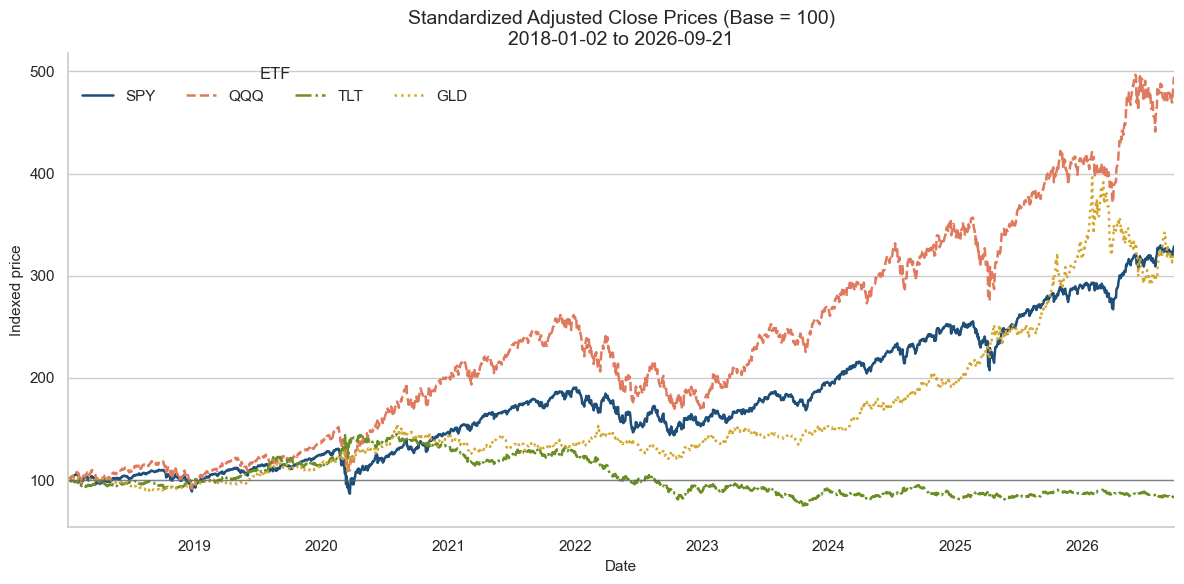

In [4]:
standardized_prices = adjusted_close.div(adjusted_close.iloc[0]).mul(100)
np.testing.assert_allclose(
    standardized_prices.iloc[0].to_numpy(),
    np.full(len(TICKERS), 100.0),
)

NORMALIZED_FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(12, 6))
for ticker in TICKERS:
    ax.plot(
        standardized_prices.index,
        standardized_prices[ticker],
        label=ticker,
        linewidth=1.8,
        **ASSET_STYLES[ticker],
    )

ax.axhline(100, color="#5F6368", linewidth=1, alpha=0.7)
ax.set_xlim(standardized_prices.index.min(), standardized_prices.index.max())
ax.set_title(
    "Standardized Adjusted Close Prices (Base = 100)\n"
    f"{standardized_prices.index.min().date()} to "
    f"{standardized_prices.index.max().date()}"
)
ax.set_xlabel("Date")
ax.set_ylabel("Indexed price")
ax.legend(title="ETF", ncol=4, loc="upper left")
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(NORMALIZED_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

### 5. Simple Daily Asset Returns

In [5]:
asset_returns = adjusted_close.pct_change(fill_method=None).iloc[1:].copy()
asset_returns.index.name = "Date"

assert asset_returns.index.equals(adjusted_close.index[1:])
assert not asset_returns.index.has_duplicates
assert asset_returns.index.is_monotonic_increasing
assert not asset_returns.isna().any().any(), "Aligned asset returns contain missing values."

return_validation = pd.Series(
    {
        "Rows": len(asset_returns),
        "Start date": asset_returns.index.min().date().isoformat(),
        "End date": asset_returns.index.max().date().isoformat(),
        "Missing values": int(asset_returns.isna().sum().sum()),
    },
    name="Return validation",
)
display(return_validation.to_frame())
display(asset_returns.head())

,Return validation
Rows,2190
Start date,2018-01-03
End date,2026-09-21
Missing values,0


Ticker,SPY,QQQ,TLT,GLD
Date,,,,
2018-01-03,0.006325,0.009717,0.004781,-0.002637
2018-01-04,0.004215,0.001749,-0.000158,0.005127
2018-01-05,0.006664,0.010043,-0.002856,-0.001036
2018-01-08,0.001829,0.003891,-0.000637,-0.000160
2018-01-09,0.002264,0.000061,-0.013373,-0.004628


### 6. Fixed-Weight Portfolio Returns

In [6]:
WEIGHTS = WEIGHTS.reindex(TICKERS)
assert np.isclose(WEIGHTS.sum(), 1.0), "Portfolio weights must sum to 1."
assert set(WEIGHTS.index) == set(asset_returns.columns)

portfolio_returns = asset_returns.dot(WEIGHTS).rename("Portfolio")
independently_recomputed = (
    0.40 * asset_returns["SPY"]
    + 0.25 * asset_returns["QQQ"]
    + 0.20 * asset_returns["TLT"]
    + 0.15 * asset_returns["GLD"]
)

assert portfolio_returns.index.equals(asset_returns.index)
assert not portfolio_returns.isna().any()
np.testing.assert_allclose(
    portfolio_returns.to_numpy(),
    independently_recomputed.to_numpy(),
    rtol=1e-12,
    atol=1e-15,
)

weight_table = WEIGHTS.rename("Weight").to_frame()
weight_table.loc["Total"] = WEIGHTS.sum()
display(weight_table.style.format("{:.0%}"))
display(portfolio_returns.head().to_frame().style.format("{:.4%}"))

,Weight
SPY,40%
QQQ,25%
TLT,20%
GLD,15%
Total,100%


,Portfolio
Date,
2018-01-03 00:00:00,0.5520%
2018-01-04 00:00:00,0.2861%
2018-01-05 00:00:00,0.4450%
2018-01-08 00:00:00,0.1553%
2018-01-09 00:00:00,-0.2448%


### 7. Descriptive Statistics

In [7]:
combined_returns = asset_returns.assign(Portfolio=portfolio_returns)
descriptive_statistics = combined_returns.describe().T.rename(
    columns={"50%": "median"}
)

display(
    descriptive_statistics.style.format(
        {
            "count": "{:,.0f}",
            "mean": "{:.4%}",
            "std": "{:.4%}",
            "min": "{:.4%}",
            "25%": "{:.4%}",
            "median": "{:.4%}",
            "75%": "{:.4%}",
            "max": "{:.4%}",
        }
    )
)

,count,mean,std,min,25%,median,75%,max
Ticker,,,,,,,,
SPY,"2,190",0.0615%,1.1987%,-10.9424%,-0.4306%,0.0848%,0.6516%,10.5019%
QQQ,"2,190",0.0843%,1.4997%,-11.9788%,-0.6096%,0.1301%,0.8620%,12.0031%
TLT,"2,190",-0.0034%,0.9661%,-6.6683%,-0.5775%,0.0093%,0.5585%,7.5196%
GLD,"2,190",0.0587%,1.0731%,-10.2742%,-0.4599%,0.0653%,0.6026%,6.3587%
Portfolio,"2,190",0.0538%,0.8842%,-6.5938%,-0.3574%,0.0943%,0.5192%,7.8741%


### 8. Asset Return Correlations

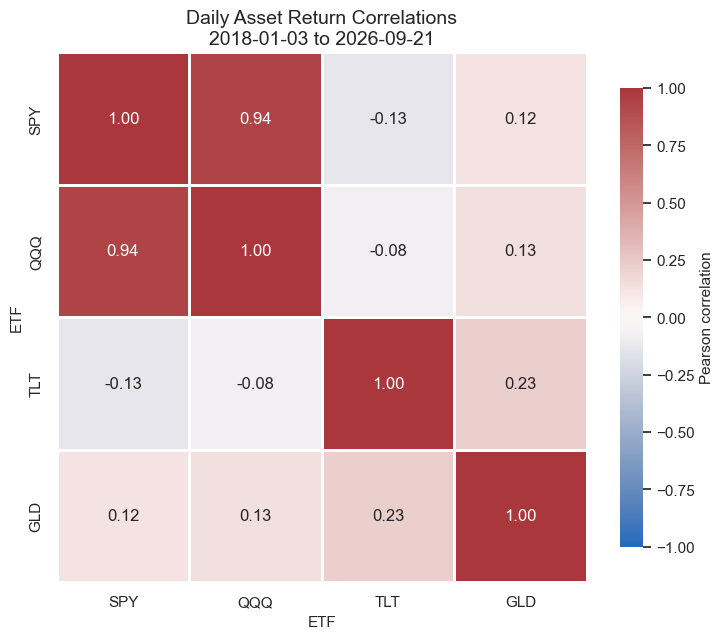

In [8]:
correlation_matrix = asset_returns.corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation", "shrink": 0.82},
    ax=ax,
)
ax.set_title(
    "Daily Asset Return Correlations\n"
    f"{asset_returns.index.min().date()} to {asset_returns.index.max().date()}"
)
ax.set_xlabel("ETF")
ax.set_ylabel("ETF")
fig.tight_layout()
fig.savefig(CORRELATION_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

### 9. Save and Re-Validate Processed Returns

In [9]:
ASSET_RETURNS_PATH.parent.mkdir(parents=True, exist_ok=True)
asset_returns.to_csv(ASSET_RETURNS_PATH)
portfolio_returns.to_frame().to_csv(PORTFOLIO_RETURNS_PATH)

saved_asset_returns = pd.read_csv(
    ASSET_RETURNS_PATH, index_col="Date", parse_dates=True
)
saved_portfolio_returns = pd.read_csv(
    PORTFOLIO_RETURNS_PATH, index_col="Date", parse_dates=True
)
saved_asset_returns.columns.name = asset_returns.columns.name

pd.testing.assert_frame_equal(
    saved_asset_returns,
    asset_returns,
    check_exact=False,
    rtol=1e-12,
    atol=1e-15,
    check_freq=False,
)
pd.testing.assert_frame_equal(
    saved_portfolio_returns,
    portfolio_returns.to_frame(),
    check_exact=False,
    rtol=1e-12,
    atol=1e-15,
    check_freq=False,
)

assert saved_asset_returns.index.equals(saved_portfolio_returns.index)
assert not saved_asset_returns.isna().any().any()
assert not saved_portfolio_returns.isna().any().any()

artifact_summary = pd.DataFrame(
    {
        "Path": [
            ASSET_RETURNS_PATH.relative_to(project_root),
            PORTFOLIO_RETURNS_PATH.relative_to(project_root),
        ],
        "Rows": [len(saved_asset_returns), len(saved_portfolio_returns)],
        "Columns": [
            saved_asset_returns.shape[1],
            saved_portfolio_returns.shape[1],
        ],
        "Missing values": [
            int(saved_asset_returns.isna().sum().sum()),
            int(saved_portfolio_returns.isna().sum().sum()),
        ],
        "Size (bytes)": [
            ASSET_RETURNS_PATH.stat().st_size,
            PORTFOLIO_RETURNS_PATH.stat().st_size,
        ],
    }
)
display(artifact_summary)
print("All alignment, weight, missing-value, and portfolio calculation checks passed.")

,Path,Rows,Columns,Missing values,Size (bytes)
0,data/processed/asset_returns.csv,2190,4,0,213232
1,data/processed/portfolio_returns.csv,2190,1,0,71625


All alignment, weight, missing-value, and portfolio calculation checks passed.


## Takeaways

- The raw file remains unchanged; cleaning is reproducible from the source CSV.
- One trailing date (`2026-09-22`) is excluded because all four `Close` prices are missing, even though non-zero Volume is recorded. Volume does not establish price validity.
- Asset and portfolio returns share the same 2,190 strictly increasing dates and contain no missing values.
- The fixed weights total exactly 100%, and portfolio returns match an independent weighted-sum calculation.
- Processed returns are ready for the next risk-model stage, but no VaR, Expected Shortfall, or backtesting is performed here.